# Notebook 6 - Probabilidad condicional y Teorema de Bayes: Humedad y viento (CDMX, 2025)

Fuente de datos: [aire.cdmx.gob.mx](https://aire.cdmx.gob.mx) -> Datos -> Meteorología, archivo "meteorología_2025.csv".

Se selecciona **una estación** de monitoreo y, sobre sus lecturas horarias de 2025, se calcula:

- **a)** P(humedad alta) = P(RH ≥ 70)
- **b)** P(viento tranquilo) = P(WSP ≤ 1)
- **c)** P(humedad alta | viento tranquilo)
- **d)** P(viento tranquilo | humedad alta)

## 0. Librerías

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
%matplotlib inline


## 1. ETL

### 1.1. Ingesta

El CSV trae 9 renglones de metadatos antes de la tabla de datos, por lo que se
omiten con "skiprows=9". Los parámetros meteorológicos vienen todos en el mismo
archivo, identificados por "id_parameter": "TMP" (temperatura), "RH" (humedad
relativa, %), "WSP" (velocidad del viento, m/s) y "WDR" (dirección del viento).


In [9]:
df = pd.read_csv("meteorología_2025.csv", skiprows=9, encoding="utf-8", engine='python', on_bad_lines='skip')
df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
df["date"] = pd.to_datetime(df["date"], errors="coerce", format="mixed")

print(df.shape)
print(df["id_parameter"].unique())
df.head()

(1191360, 5)
['TMP' 'RH' 'WSP' 'WDR']


,date,id_station,id_parameter,valor,unit
0,2025-01-01,ACO,TMP,8.7,5
1,2025-01-01,ACO,RH,28.0,6
2,2025-01-01,ACO,WSP,2.4,3
3,2025-01-01,ACO,WDR,2.0,4
4,2025-01-01,AJM,TMP,9.6,5


### 1.2. Selección de estación

Se elige la estación con mayor cobertura de datos (menos lecturas faltantes)
en 2025 para los parámetros de interés ("RH" y "WSP"), de modo que las
probabilidades estimadas sean más confiables.


In [10]:
cobertura = (
    df[df["id_parameter"].isin(["RH", "WSP"])]
    .groupby("id_station")["valor"]
    .apply(lambda x: x.notna().sum())
    .sort_values(ascending=False)
)
cobertura.head(10)


,valor
id_station,
UAX,17514
MER,17485
CUT,17472
AJM,17467
MGH,17463
PED,17371
NEZ,15630
UIZ,14971
MPA,14553


In [11]:
ESTACION = cobertura.index[0]
print(f"Estación seleccionada: {ESTACION} ({cobertura.iloc[0]:,} lecturas válidas de RH/WSP)")


Estación seleccionada: UAX (17,514 lecturas válidas de RH/WSP)


### 1.3. Limpieza y feature engineering

Se filtra el DataFrame a la estación seleccionada, se pivotea para tener una
fila por "date" con columnas "RH" y "WSP", y se eliminan las horas donde falte
alguna de las dos lecturas (necesarias ambas para calcular la probabilidad
conjunta).

Además se crean dos columnas booleanas (features derivados) que marcan los
eventos de interés:

- "humedad_alta": "RH >= 70"
- "viento_tranquilo": "WSP <= 1"


In [12]:
df_estacion = df[df["id_station"] == ESTACION]

df_meteo = df_estacion.pivot_table(
    index="date", columns="id_parameter", values="valor", aggfunc="first"
)

df_meteo = df_meteo.dropna(subset=["RH", "WSP"])

df_meteo["humedad_alta"] = df_meteo["RH"] >= 70
df_meteo["viento_tranquilo"] = df_meteo["WSP"] <= 1

print("Horas con lectura válida de RH y WSP en", ESTACION, ":", len(df_meteo))
df_meteo.head()


Horas con lectura válida de RH y WSP en UAX : 8757


id_parameter,RH,TMP,WDR,WSP,humedad_alta,viento_tranquilo
date,,,,,,
2025-01-01 00:00:00,41.0,13.3,231.0,1.1,False,False
2025-01-01 01:00:00,45.0,12.1,193.0,1.1,False,False
2025-01-01 02:00:00,46.0,11.2,199.0,1.0,False,True
2025-01-01 03:00:00,55.0,9.9,18.0,0.2,False,True
2025-01-01 04:00:00,55.0,9.3,145.0,1.1,False,False


## 2. Probabilidades individuales

### a) Probabilidad de humedad alta: P(RH >= 70)


In [13]:
n_total = len(df_meteo)
n_humedad_alta = df_meteo["humedad_alta"].sum()

p_humedad_alta = n_humedad_alta / n_total
print(f"P(humedad alta) = P(RH >= 70) = {n_humedad_alta}/{n_total} = {p_humedad_alta:.4f} ({p_humedad_alta*100:.2f}%)")


P(humedad alta) = P(RH >= 70) = 3138/8757 = 0.3583 (35.83%)


### b) Probabilidad de viento tranquilo: P(WSP <= 1)

In [14]:
n_viento_tranquilo = df_meteo["viento_tranquilo"].sum()

p_viento_tranquilo = n_viento_tranquilo / n_total
print(f"P(viento tranquilo) = P(WSP <= 1) = {n_viento_tranquilo}/{n_total} = {p_viento_tranquilo:.4f} ({p_viento_tranquilo*100:.2f}%)")


P(viento tranquilo) = P(WSP <= 1) = 1938/8757 = 0.2213 (22.13%)


## 3. Probabilidad conjunta

Para poder aplicar el Teorema de Bayes primero se necesita la probabilidad de que ambos eventos ocurran al mismo tiempo: P(humedad alta ∩ viento tranquilo).


In [15]:
n_conjunto = (df_meteo["humedad_alta"] & df_meteo["viento_tranquilo"]).sum()
p_conjunto = n_conjunto / n_total

print(f"P(humedad alta ∩ viento tranquilo) = {n_conjunto}/{n_total} = {p_conjunto:.4f} ({p_conjunto*100:.2f}%)")


P(humedad alta ∩ viento tranquilo) = 1306/8757 = 0.1491 (14.91%)


## 4. Probabilidades condicionales (Teorema de Bayes)

### c) P(humedad alta | viento tranquilo)

$$P(\text{humedad alta} \mid \text{viento tranquilo}) = \frac{P(\text{humedad alta} \cap \text{viento tranquilo})}{P(\text{viento tranquilo})}$$


In [16]:
p_humedad_dado_viento = p_conjunto / p_viento_tranquilo

print(
    f"P(humedad alta | viento tranquilo) = {p_conjunto:.4f} / {p_viento_tranquilo:.4f} "
    f"= {p_humedad_dado_viento:.4f} ({p_humedad_dado_viento*100:.2f}%)"
)


P(humedad alta | viento tranquilo) = 0.1491 / 0.2213 = 0.6739 (67.39%)


### d) P(viento tranquilo | humedad alta)

Usando el Teorema de Bayes a partir de lo ya calculado:

$$P(\text{viento tranquilo} \mid \text{humedad alta}) = \frac{P(\text{humedad alta} \mid \text{viento tranquilo}) \cdot P(\text{viento tranquilo})}{P(\text{humedad alta})}$$


In [17]:
p_viento_dado_humedad_bayes = (
    p_humedad_dado_viento * p_viento_tranquilo
) / p_humedad_alta

# Verificación directa (debe dar el mismo resultado):
p_viento_dado_humedad_directa = p_conjunto / p_humedad_alta

print(f"P(viento tranquilo | humedad alta) [Bayes]  = {p_viento_dado_humedad_bayes:.4f} ({p_viento_dado_humedad_bayes*100:.2f}%)")
print(f"P(viento tranquilo | humedad alta) [directo] = {p_viento_dado_humedad_directa:.4f} ({p_viento_dado_humedad_directa*100:.2f}%)")


P(viento tranquilo | humedad alta) [Bayes]  = 0.4162 (41.62%)
P(viento tranquilo | humedad alta) [directo] = 0.4162 (41.62%)


## 5. Resumen


In [18]:
resumen = pd.DataFrame({
    "Probabilidad": [
        "a) P(humedad alta)          = P(RH >= 70)",
        "b) P(viento tranquilo)      = P(WSP <= 1)",
        "   P(humedad alta ∩ viento tranquilo)",
        "c) P(humedad alta | viento tranquilo)",
        "d) P(viento tranquilo | humedad alta)",
    ],
    "Valor": [
        p_humedad_alta,
        p_viento_tranquilo,
        p_conjunto,
        p_humedad_dado_viento,
        p_viento_dado_humedad_bayes,
    ],
})
resumen["Valor (%)"] = (resumen["Valor"] * 100).round(2)
resumen["Valor"] = resumen["Valor"].round(4)
resumen


,Probabilidad,Valor,Valor (%)
0,a) P(humedad alta) = P(RH >= 70),0.3583,35.83
1,b) P(viento tranquilo) = P(WSP <= 1),0.2213,22.13
2,P(humedad alta ∩ viento tranquilo),0.1491,14.91
3,c) P(humedad alta | viento tranquilo),0.6739,67.39
4,d) P(viento tranquilo | humedad alta),0.4162,41.62


## 6. Visualización

Comparación de las probabilidades marginales, conjunta y condicionales de la
estación  para tener una lectura visual rápida del resultado.


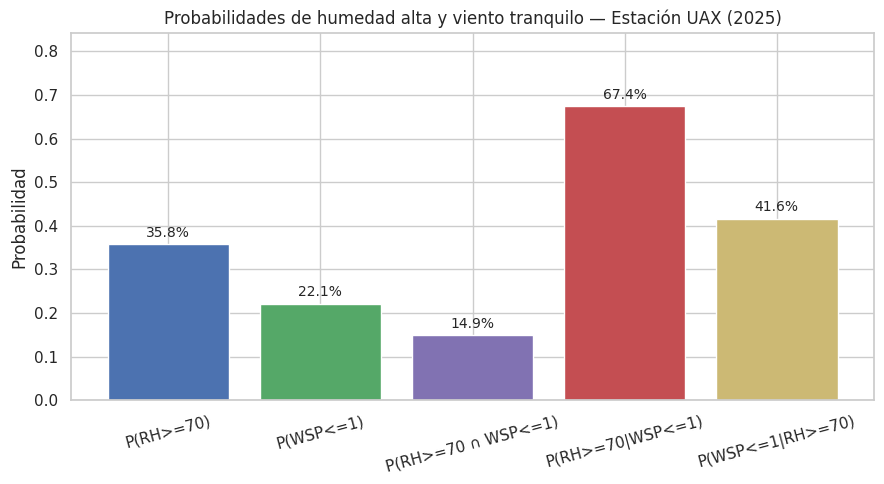

In [19]:
etiquetas = ["P(RH>=70)", "P(WSP<=1)", "P(RH>=70 ∩ WSP<=1)", "P(RH>=70|WSP<=1)", "P(WSP<=1|RH>=70)"]
valores = [p_humedad_alta, p_viento_tranquilo, p_conjunto, p_humedad_dado_viento, p_viento_dado_humedad_bayes]

plt.figure(figsize=(9, 5))
barras = plt.bar(etiquetas, valores, color=["#4C72B0", "#55A868", "#8172B2", "#C44E52", "#CCB974"])
plt.ylabel("Probabilidad")
plt.title(f"Probabilidades de humedad alta y viento tranquilo — Estación {ESTACION} (2025)")
plt.ylim(0, max(valores) * 1.25)

for barra, valor in zip(barras, valores):
    plt.text(barra.get_x() + barra.get_width() / 2, valor + 0.01, f"{valor*100:.1f}%",
              ha="center", va="bottom", fontsize=10)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 7. Conclusiones

Con los datos horarios de 2025 de la estación seleccionada se estimaron las probabilidades marginales de humedad alta (RH >= 70) y viento tranquilo (WSP <= 1), así como su probabilidad conjunta.

A partir de estas se obtuvieron las probabilidades condicionales en ambos sentidos, comprobando que el Teorema de Bayes y el cálculo directo (P(A∩B)/P(B)) dan el mismo resultado.

Si P(humedad alta | viento tranquilo) > P(humedad alta), significa que la humedad alta es más frecuente cuando el viento está tranquilo que en general: es decir, los dos eventos están relacionados positivamente en esta estación.
